# 101. LSSTCam visits database

<div style="max-width:300px; float: left; margin-right: 1em">

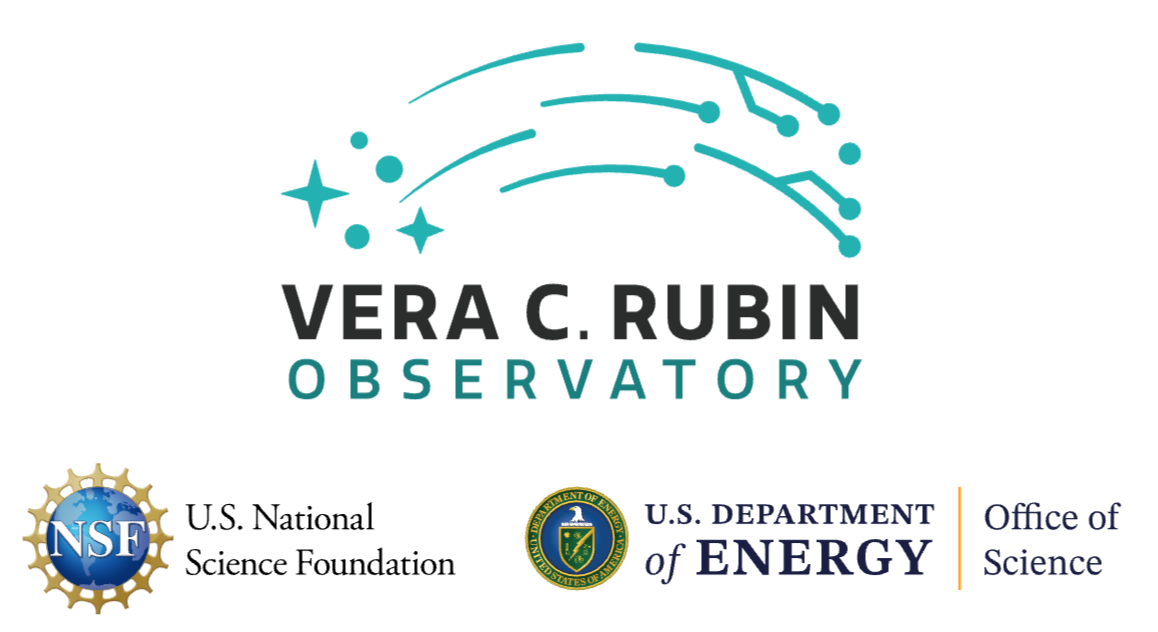

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Container Size: Large\
LSST Science Pipelines version: v29.2.0\
Last verified to run: 2026-01-28\
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a>\
DOI: <a href="https://doi.org/10.11578/rubin/dc.20250909.20">10.11578/rubin/dc.20250909.20</a>

**Learning objective:** How to query and retrieve data from the commissioning visits database file.

**LSST data products:** The `lsstcam_20250930.db` file available on the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html'> Science Validation survey summary webpage </a>.

**Packages:** `sqlite3`, `rubin_sim`

**Credit:** Developed by the Rubin Community Science team, using materials from the Rubin Survey Scheduling team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial demonstrates how to query and load data from the SQL-formatted table of commissioning visits that is available on the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html'> Science Validation survey summary webpage </a> and also as a shared file in the Rubin Science Platform.

**This is a temporary, static database file with non-standard schema and formatting, which only includes LSSTCam visits obtained prior to Sep 30 2025, and which is provided as a convenience.** 

For more recent visits and a forecast of the Rubin scheduler, see the tutorial notebook for the Rubin Schedule Viewer.
The future Rubin data releases will similar information in their `Visit` and `CcdVisit` tables.

**Science Validation surveys.**

It is recommended to review the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html'> Science Validation survey summary webpage </a> for details on the strategy and results of the commissioning surveys.

Science images with LSSTCam began on 04 April 2025, at first acquiring small field survey visits in sequences of $\sim10$ visits per filter with small dithers, similar to the LSSTComCam strategy which resulted in Data Preview 1. These small field survey visits included the images which contributed toward <a href="https://rubinobservatory.org/news/rubin-first-look">Rubin First Look</a>.

The Science Validation (SV) survey began on 20 June 2025, acquiring visits in a manner consistent with the planned operations survey for the LSST, but within a limited area.
The contiguous part of the SV area follows the ecliptic plane from dense regions of the Galactic Bulge through low-dust regions within the planned LSST Wide Fast Deep (WFD).
Four of the planned LSST Deep Drilling Fields (DDFs) were included in the SV survey, and a secondary area within the low-dust WFD was included to provide targets when the primary or DDF fields were not available.

<div style="max-width:500px">

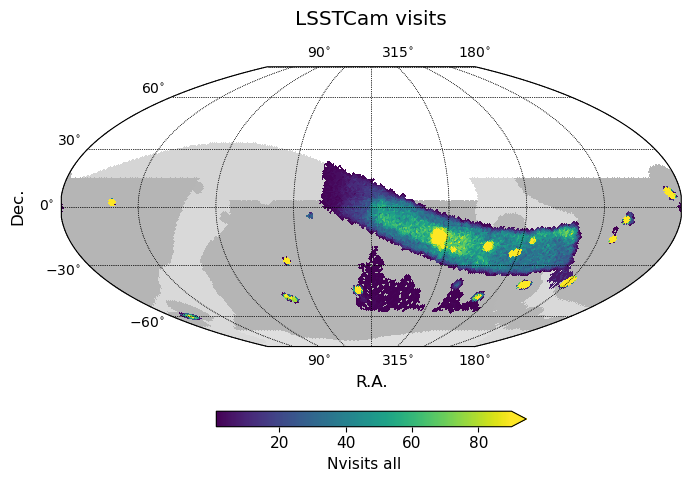

</div>

> **Figure 1:** All science visits acquired during LSSTCam commissioning. Both the small field surveys and the four SV DDFs appear as non-contiguous yellow regions in this plot. This plot is from the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html'> Science Validation survey summary webpage </a>, and instructions for recreating a version of it are in Section 5.

**Caveats.**

* **Image quality (IQ) is variable.** The database file includes a total of 21647 commissioning visits. This excludes bad visits, but includes visits with a wide range of data quality due to both cloud extinction and/or delivered IQ or engineering issues. Keep in mind that while these observations were obtained, the Active Optics System (AOS) was being commissioned and it was winter.
* **Not all of these visits will be in Data Preview 2 (DP2).** Although an initial cut of bad visits have been made, users should expect that additional cuts will be made to the visits that are included and released as part of DP2.
* **Measured IQ values may change.** Some columns contain NaNs, where the summit quicklook processing did not provide a useful value. Many of these problems will be resolved with later processing. Users should anticipate that some measured IQ values will change.

### 1.1. Import packages

Import `sqlite3` to read the SQL-formatted database file, and import the `maf` module from the `rubin_sim` package to use the (<a href='https://rubin-sim.lsst.io/maf.html'>Metric Analysis Framework</a>) functions. Also import standard python science packages and the `lsst.utils.plotting` package.

In [1]:
# pip install lsst-utils

In [2]:
import sqlite3
from rubin_sim import maf

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate
from astropy.time import Time
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_linestyles)

## Ma config locale

In [3]:
os.environ['RUBIN_SIM_DATA_DIR'] = os.path.expanduser('~/rubin_sim_data')
os.environ['SCRATCH_DIR'] = os.path.expanduser('~/Desktop/RubinLSSTDP1Data/scratch')
os.makedirs(os.environ['SCRATCH_DIR'], exist_ok=True)

### 1.2. Define parameters

Define the path and name of the database file.

In [4]:
#db_filename = '/rubin/cst_repos/tutorial-notebooks-data/data/lsstcam_20250930.db'
db_filename = './lsstcam_20250930.db'

Define the default path for output files. Use the shared scratch directory, `/deleted-sundays/`, and create a subdirectory with your username if one does not already exist.

In [5]:
output_path = os.getenv('SCRATCH_DIR')
if os.path.exists(output_path):
    print('Already exists: ', output_path)
else:
    os.system('mkdir ' + output_path)
    print('Created: ', output_path)

Already exists:  /Users/dagoret/Desktop/RubinLSSTDP1Data/scratch


Define the LSST filter names and the colors and linestyles to represent the filters.

In [6]:
filter_names = ['u', 'g', 'r', 'i', 'z', 'y']
filter_colors = get_multiband_plot_colors()
filter_linestyles = get_multiband_plot_linestyles()
filter_colors_list = [filter_colors['u'], filter_colors['g'],
                      filter_colors['r'], filter_colors['i'],
                      filter_colors['z'], filter_colors['y']]

## 2. Explore the database

The information contained in the database is an aggregation of entries in the "Consolidate Database" (ConsDB), including per-visit summary values from summit quicklook processing (the ConsDB is not yet released to users). The database generally follows the current LSST scheduler output schema, but additional columns were added in post-processing. Rubin data releases have similar information in their `Visit` and `CcdVisit` tables.

As this is an aggregate file, descriptions for its columns can be found among those at:
* <a href="https://sdm-schemas.lsst.io/cdb_lsstcam.html">ConsDB Schema</a>
* <a href="https://rubin-scheduler.lsst.io/fbs-output-schema.html">Scheduler Output Schema</a>


### 2.1. Key columns

The database contains 217 columns in total, but these are the key columns used in this tutorial.

* `observation_reason` : The source of the visit in the Feature Based Scheduler (FBS).
* `target_name` : The name of the sky region for the visit.
* `exp_midpt_mjd` : The midpoint time of the exposure at the fiducial center of the focal plane (in TAI).
* `fieldRA` : The boresight Right Ascension for the visit (degrees).
* `fieldDec` : The boresight Declination for the visit (degrees).
* `band` : The LSST filter used for the visit, one of $ugrizy$.
* `airmass` : The airmass of the visit ($1/\cos(\Theta_z)$, where $\Theta_z$ is the zenith angle).
* `seeingFwhmEff` : The full-width half-max of the point spread function (PSF; arcseconds).
* `fiveSigmaDepth` : The magnitude of a five-sigma point source detection in the visit (magnitudes).


### 2.2. Connect with sqlite3

Connect to the database file using `sqlite3`.

In [7]:
db_conn = sqlite3.connect(db_filename)
cursor = db_conn.cursor()

#### 2.2.1. Explore the schema

Print the names of all tables in the database. There is only one, the `observations` table.

In [8]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
table_names = [table[0] for table in tables]
print("Tables:", table_names)
del tables, table_names

Tables: ['observations']


Option to print the schema (column names and types) for the `observations` table. It is a long list, and not printed by default.

In [9]:
# table_name = 'observations'
# query = f"""SELECT sql FROM sqlite_master WHERE type='table'
#             AND name='{table_name}';"""
# cursor.execute(query)
# create_table_sql = cursor.fetchone()[0]
# print(f"Schema for {table_name}:\n{create_table_sql}")
# del query, table_name, create_table_sql

#### 2.2.2. Query the database

As an example, create a query to return columns `fieldRA`, `fieldDec`, and `band` from the `observations` table for all $r$-band visits obtained at an airmass less than 1.5 and with an `observation_reason` of "field_survey_science".
The column `observation_reason` is discussed in Section 3.1. 

In [10]:
query = """SELECT fieldRA, fieldDec, band FROM observations
           WHERE observation_reason = 'field_survey_science'
           AND band='r' AND airmass < 1.5; """
cursor.execute(query)
results = cursor.fetchall()
print("Number of rows returned: ", len(results))

Number of rows returned:  1521


Option to display the query results.

In [11]:
# results

Clean up, and close the connection with the database.

In [12]:
del query, results

cursor.close()
del cursor

### 2.3. Read as a pandas dataframe

As the file is only 81 M, it is small enough to be loaded in its entirety as a `pandas` dataframe.

Read the SQL-formatted table as a pandas dataframe, `df`, and print the number of rows.

In [13]:
df = pd.read_sql_query("SELECT * FROM observations", db_conn)
print(len(df))

21647


Option to display the table (it will automatically truncate).

In [14]:
df

,observationId,exposure_name,controller,day_obs,seq_num,physical_filter,band,fieldRA,fieldDec,rotSkyPos,...,fiveSigmaDepth,slew_model,slew_model_ideal,model_gap,slewDistance,overhead,fault,jd,nexp,night
0,2025041700758,MC_O_20250417_000758,O,20250417,758,i_39,i,225.869202,-39.527387,-54.862885,...,NaN,240.526259,81.608753,-240.526259,0.000000,0.000000,0.000000,2460783.0,1,-64.0
1,2025041700759,MC_O_20250417_000759,O,20250417,759,i_39,i,226.268702,-40.008823,-59.077550,...,NaN,6.858416,4.318507,5.687223,0.571026,12.545639,0.000000,2460783.0,1,-64.0
2,2025041700760,MC_O_20250417_000760,O,20250417,760,i_39,i,226.444946,-39.959390,-62.142548,...,NaN,4.791784,3.826579,7.327090,0.143805,10.791784,1.327090,2460783.0,1,-64.0
3,2025041800614,MC_O_20250418_000614,O,20250418,614,i_39,i,216.685865,-12.029763,22.059364,...,NaN,18.798711,18.798711,77634.726373,30.148502,24.798711,77628.726373,2460784.0,1,-63.0
4,2025041800616,MC_O_20250418_000616,O,20250418,616,i_39,i,216.200838,-16.632809,11.119396,...,NaN,9.027262,8.769682,472.524291,4.190098,15.027262,466.524291,2460784.0,1,-63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21642,2025092100143,MC_O_20250921_000143,O,20250921,143,z_20,z,319.982025,-15.815555,67.659510,...,22.744551,7.753213,5.776606,2.744771,3.135852,10.497984,0.000000,2460940.0,1,93.0
21643,2025092100144,MC_O_20250921_000144,O,20250921,144,i_39,i,322.939232,-14.489960,75.465433,...,23.254149,140.000000,120.000000,2.243840,3.147092,142.243840,0.000000,2460940.0,1,93.0
21644,2025092100145,MC_O_20250921_000145,O,20250921,145,i_39,i,322.989869,-11.711687,79.448944,...,23.218998,9.323559,6.082373,3.361709,2.778710,12.685267,0.000000,2460940.0,1,93.0
21645,2025092100146,MC_O_20250921_000146,O,20250921,146,i_39,i,320.163925,-10.263107,76.176356,...,23.150885,7.633885,5.716942,2.846436,3.129494,10.480321,0.000000,2460940.0,1,93.0


Option to print the column names.

In [15]:
list(df.columns)

['observationId',
 'exposure_name',
 'controller',
 'day_obs',
 'seq_num',
 'physical_filter',
 'band',
 'fieldRA',
 'fieldDec',
 'rotSkyPos',
 'azimuth_start',
 'azimuth_end',
 'azimuth',
 'altitude_start',
 'altitude_end',
 'altitude',
 'zenith_distance_start',
 'zenith_distance_end',
 'zenith_distance',
 'airmass',
 'exp_midpt',
 'exp_midpt_mjd',
 'obs_start',
 'observationStartMJD',
 'obs_end',
 'obs_end_mjd',
 'visitExposureTime',
 'shut_time',
 'visitTime',
 'group_id',
 'cur_index',
 'max_index',
 'img_type',
 'emulated',
 'science_program',
 'observation_reason',
 'target_name',
 'air_temp',
 'pressure',
 'humidity',
 'wind_speed',
 'wind_dir',
 'dimm_seeing',
 'focus_z',
 'simulated',
 'vignette',
 'vignette_min',
 'scheduler_note',
 's_region',
 'can_see_sky',
 'n_inputs',
 'pixel_scale_min',
 'pixel_scale_max',
 'pixel_scale_median',
 'astrom_offset_mean_min',
 'astrom_offset_mean_max',
 'astrom_offset_mean_median',
 'astrom_offset_std_min',
 'astrom_offset_std_max',
 'astro

## 3. Surveys and targets

Every visit has both an `observation_reason` and a `target_name`.

The `observation_reason` is the motivation as to why the visit was obtained.
In other words, it indicates the scheduler mode or the survey.
For this database, for example, observation reasons include the SV WFD configurations, the SV DDF programs, target of opportunity (ToO), and the small field surveys.

The `target_name` is either a region of the LSST WFD (e.g., bulge, low-dust) or a proper name (for DDFs, or the commissioning small field survey fields).
Since regions can overlap, or a single visit can overlap the boundaries of multiple regions, the `target_name` is often a comma-separated list.
For example, most DDFs are also in the low-dust extragalactic regions of the LSST WFD.

### 3.1. Observation reason

Print the unique values of the `observation_reason` column and the number of visits for each.

In [16]:
values, counts = np.unique(df['observation_reason'], return_counts=True)
for value, count in zip(values, counts):
    print('%25s %5i' % (value, count))

                ddf_ecdfs   160
               ddf_edfs_a    87
               ddf_edfs_b    92
              ddf_elaiss1   539
              ddf_xmm_lss    30
     field_survey_science  7194
                    pairs   400
            pairs_gr_33.0  1176
            pairs_iz_15.0   399
            pairs_iz_33.0  2283
            pairs_ri_15.0   764
            pairs_ri_33.0  1341
            pairs_ug_33.0   192
            pairs_ur_33.0    46
            pairs_yy_15.0   117
            pairs_yy_33.0  1509
            pairs_zy_15.0     1
            pairs_zy_33.0   594
                singles_i    19
                singles_r     7
                singles_z   708
  template_area_singles_i   111
     template_blob_g_33.0   546
     template_blob_i_33.0   553
     template_blob_r_33.0   843
     template_blob_u_33.0   602
     template_blob_y_33.0   260
     template_blob_z_33.0   500
                      too   194
    triplet_pairs_gr_33.0   286
    triplet_pairs_iz_33.0    94


Print the number of visits done for small field surveys, deep drilling fields, target of opportunity, and template creation.

In [17]:
Nsfs = len(df.query("observation_reason == 'field_survey_science'"))
Nddf = len(df.query("observation_reason.str.contains('ddf')"))
Ntoo = len(df.query("observation_reason.str.contains('too')"))
Ntas = len(df.query("observation_reason == 'template_area_singles_i'"))

print("Number of visits done for small field surveys: ", Nsfs)
print("Number of visits done for SV DDFs: ", Nddf)
print("Number of visits done for target of opportuntity: ", Ntoo)
print("Number of visits done for templates: ", Ntas)

Number of visits done for small field surveys:  7194
Number of visits done for SV DDFs:  908
Number of visits done for target of opportuntity:  194
Number of visits done for templates:  111


Print the number of visits done as part of the primary wide LSST Science Validation (SV WFD -- excluding the SV DDFs and all the other observation reasons above).

In [18]:
Nwfd = len(df) - Nsfs - Nddf - Ntoo - Ntas
print("Number of visits done for the SV WFD: ", Nwfd)

Number of visits done for the SV WFD:  13240


Clean up.

In [19]:
del Nsfs, Nddf, Ntoo, Ntas, Nwfd

### 3.2. Target names

#### 3.2.1. Small field surveys

Get the unique values of `target_name` for each of the small field survey areas, and print the number of visits done for each.

In [20]:
df_sfs = df.query("observation_reason == 'field_survey_science'")
values, counts = np.unique(df_sfs['target_name'], return_counts=True)
for value, count in zip(values, counts):
    print('%20s %5i' % (value, count))
del df_sfs, values, counts

          Abell_2764     7
              COSMOS   664
              Carina   124
             DEEP_A0     1
         DESI_SV3_R1     4
            ELAIS_S1   166
                 M49  1173
        New_Horizons   360
               Prawn   632
     Rubin_SV_212_-7   498
    Rubin_SV_216_-17   386
    Rubin_SV_225_-40  2052
    Rubin_SV_280_-48   148
    Rubin_SV_300_-41    38
    Rubin_SV_320_-15   273
       Trifid-Lagoon   668


Note that in the table of small field survey visits on the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html#small-field-survey-visits'> Science Validation survey summary webpage </a>, only survey fields with >50 visits are shown.

#### 3.2.2. Wide-fast-deep regions

Get the unique values of `target_name` for visits done as part of the WFD LSST Science Validation survey program.

For this database, it is simpler to start by defining the `observation_reason` values that **are not** part of the SV WFD  (i.e., exclude SV DDFs, ToO, small field surveys, and the template-building observations).

In [21]:
query = "(observation_reason != 'field_survey_science') & "
query += "(observation_reason.str.contains('ddf') == 0) & "
query += "(observation_reason.str.contains('too') == 0) & "
query += "(observation_reason != 'template_area_singles_i')"
df_wfd = df.query(query)

values, counts = np.unique(df_wfd['target_name'], return_counts=True)
for value, count in zip(values, counts):
    print('%30s %5i' % (value, count))

                         bulgy  2600
            bulgy, dusty_plane    81
                bulgy, lowdust   121
                   dusty_plane   996
            dusty_plane, bulgy   166
   dusty_plane, bulgy, lowdust     7
          dusty_plane, lowdust   114
                       lowdust  8412
                lowdust, bulgy    36
          lowdust, dusty_plane    66
                  lowdust, nes    94
                           nes   441
                  nes, lowdust   106


Separate out the comma-separated lists into one list of unique target names.

In [22]:
temp = []
for value in values:
    for name in str(value).split(','):
        temp.append(name.strip())
targets = np.unique(temp)
print(targets)

['bulgy' 'dusty_plane' 'lowdust' 'nes']


The unique LSST region target names covered during commissioning are:

* `bulgy` - Galactic bulge region
* `lowdust` - low dust sky region
* `dusty_plane` - dusty regions of the Galactic plane
* `nes` - North Ecliptic Spur (NES)

Learn more about all of the planned LSST WFD regions on the <a href="https://survey-strategy.lsst.io/baseline/index.html">LSST Baseline Strategy webpage</a>.

Sum up the number of visits that overlap with each unique target name.

In [23]:
for target in targets:
    print('%15s %5i' % (target, len(df_wfd.query("target_name.str.contains(@target)"))))

          bulgy  3011
    dusty_plane  1430
        lowdust  8956
            nes   641


Clean up.

In [24]:
del query, df_wfd, values, counts, temp, targets

#### 3.2.3. Deep Drilling Fields (DDFs)

The LSST will include five <a href="https://survey-strategy.lsst.io/baseline/ddf.html">Deep Drilling Fields</a>,
four of which (all except COSMOS) were observed as part of the LSST Science Validation survey.

<div style="max-width:500px">

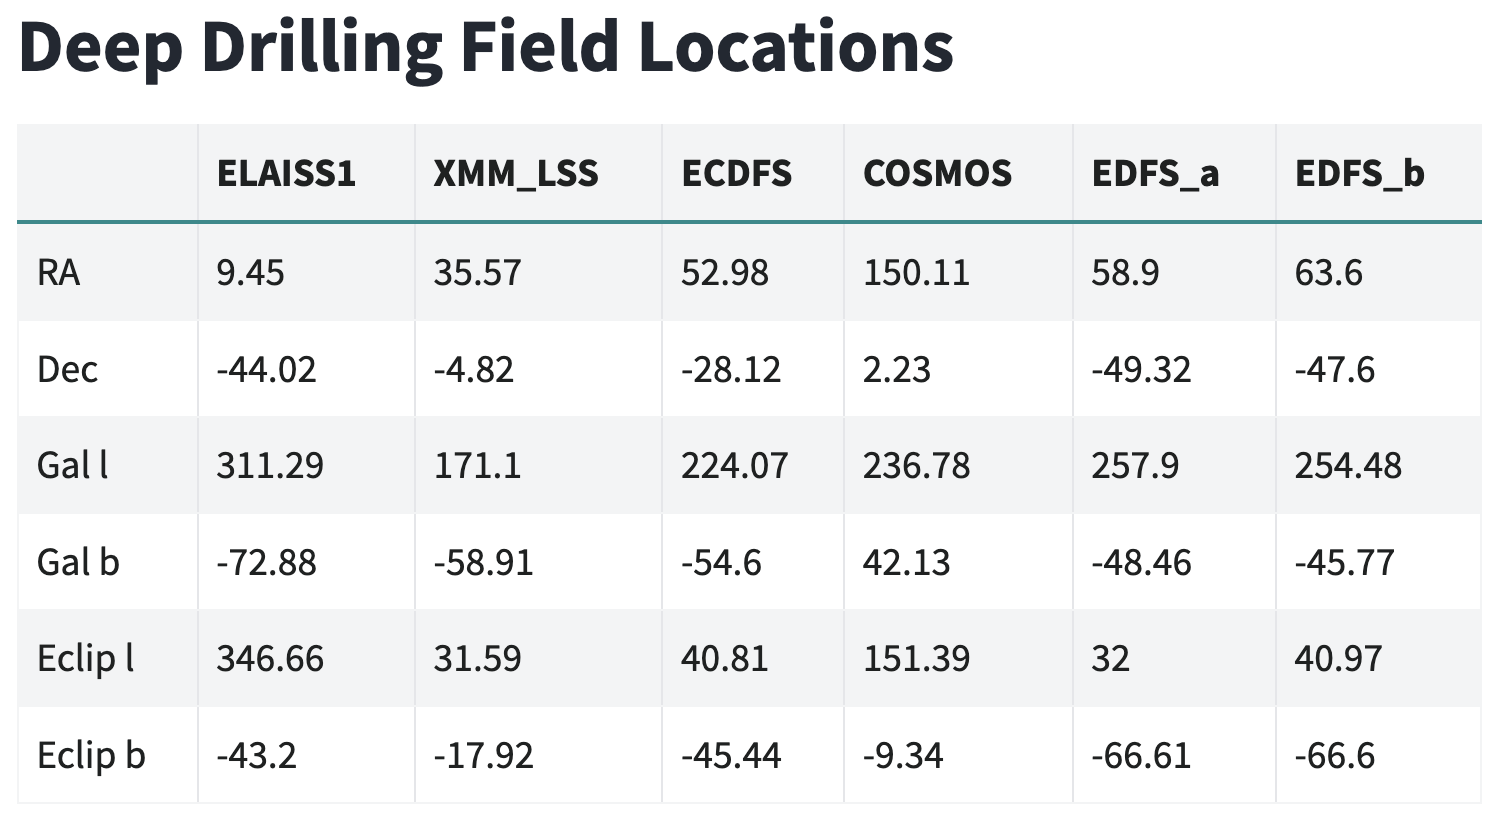

</div>

> **Table 1:** DDF locations, from <a href="https://survey-strategy.lsst.io/baseline/ddf.html#deep-drilling-field-locations">the DDF webpage</a>.


Print the unique DDF target names and the number of visits done for each.

In [25]:
df_ddf = df.query("observation_reason.str.contains('ddf')")
values, counts = np.unique(df_ddf['target_name'], return_counts=True)
for value, count in zip(values, counts):
    print('%20s %5i' % (value, count))

  DDF ECDFS, lowdust   119
 DDF EDFS_a, lowdust    55
 DDF EDFS_b, lowdust    58
DDF ELAISS1, lowdust   269
DDF XMM_LSS, lowdust     6
  lowdust, DDF ECDFS    41
 lowdust, DDF EDFS_a    32
 lowdust, DDF EDFS_b    34
lowdust, DDF ELAISS1   270
lowdust, DDF XMM_LSS    24


The DDFs overlap the WFD lowdust region, and so the fields have both the DDF name and "lowdust" in their `target_name`.

Separate out the comma-separated lists into one list of unique target names.

In [26]:
temp = []
for value in values:
    for name in str(value).split(','):
        temp.append(name.strip())
targets = np.unique(temp)
print(targets)

['DDF ECDFS' 'DDF EDFS_a' 'DDF EDFS_b' 'DDF ELAISS1' 'DDF XMM_LSS'
 'lowdust']


Define the list of only the DDF target names.

In [27]:
ddf_names = ['DDF ECDFS', 'DDF EDFS_a', 'DDF EDFS_b', 'DDF ELAISS1', 'DDF XMM_LSS']

Sum up the number of visits for each SV DDF.

In [28]:
for name in ddf_names:
    print('%15s %5i' % (name, len(df_ddf.query("target_name.str.contains(@name)"))))

      DDF ECDFS   160
     DDF EDFS_a    87
     DDF EDFS_b    92
    DDF ELAISS1   539
    DDF XMM_LSS    30


Clean up.

In [29]:
del df_ddf, values, counts, temp, targets, ddf_names

## 4. Visit metadata

Examples of how to visualize and calculate statistics for a few key columns of visit metadata.

### 4.1. Plot histograms

Create a histogram of the Modified Julian Dates of all visits, stacked by filter.

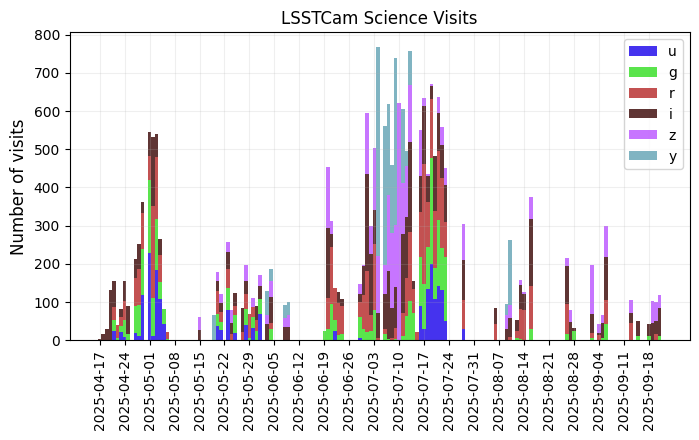

In [30]:
t = Time("2025-04-17T12:00:00", scale='tai')
mjd_to_jd = t.mjd - t.jd
df.loc[:, 'jd'] = np.floor(df.observationStartMJD - mjd_to_jd)
df.loc[:, 'jd'] = df.jd.astype(int)
jds = np.arange(df.jd.min(), df.jd.max()+1, 1)
jdsbins = np.arange(df.jd.min(), df.jd.max()+2, 1)
days = [t.split('T')[0] for t in Time(jds, format='jd', scale='tai').isot]
bar_bottom = np.zeros(len(jds))

plt.figure(figsize=(8, 4))
for b in 'ugrizy':
    heights, _ = np.histogram(df.query("band == @b ").jd, bins=jdsbins)
    plt.bar(jds, heights, bottom=bar_bottom, width=1, color=filter_colors[b], alpha=0.8, label=b)
    bar_bottom += heights
plt.legend()
_ = plt.xticks(jds[::7], labels=days[::7], rotation=90)
plt.grid(alpha=0.2)
plt.ylabel("Number of visits", fontsize='large')
plt.title("LSSTCam Science Visits")
plt.show()

> **Figure 2:** The number of visits per filter over time, in days.

Create a histogram of the airmass of each visit, by filter.

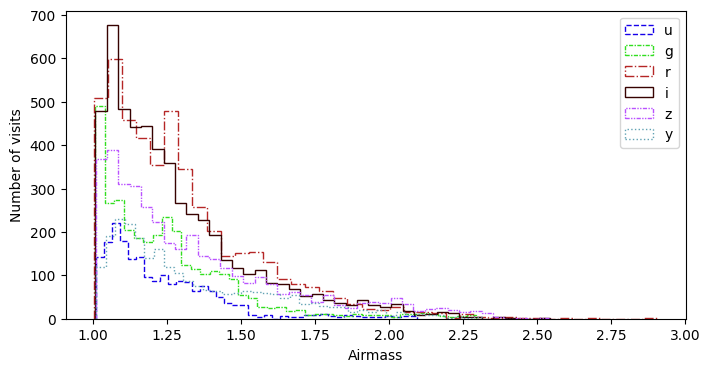

In [31]:
fig = plt.figure(figsize=(8, 4))
for f, filt in enumerate(filter_names):
    plt.hist(df.query("band == @filt")['airmass'],
             bins=40, histtype='step',
             ls=filter_linestyles[filt],
             color=filter_colors_list[f], label=filt)
plt.legend(loc='best')
plt.xlabel("Airmass")
plt.ylabel("Number of visits")
plt.show()

> **Figure 3:** The number of visits in bins of airmass, by filter.

Create a histogram of the measured seeing of each visit, by filter.

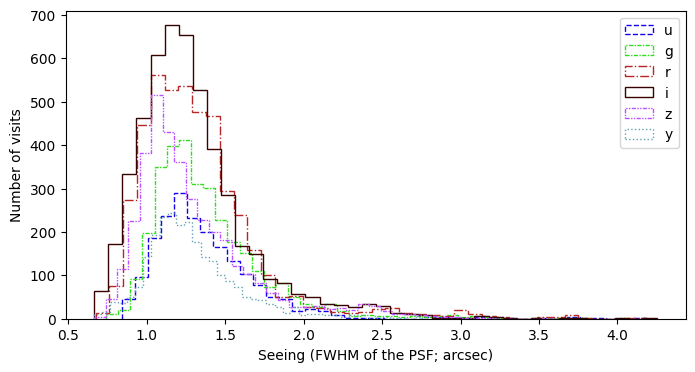

In [32]:
fig = plt.figure(figsize=(8, 4))
for f, filt in enumerate(filter_names):
    plt.hist(df.query("band == @filt")['seeingFwhmEff'],
             bins=40, histtype='step',
             ls=filter_linestyles[filt],
             color=filter_colors_list[f], label=filt)
plt.legend(loc='best')
plt.xlabel("Seeing (FWHM of the PSF; arcsec)")
plt.ylabel("Number of visits")
plt.show()

> **Figure 4:** The number of visits in bins of seeing, by filter.

Create a histogram of the $5\sigma$ depth (for point sources) of each visit, by filter.

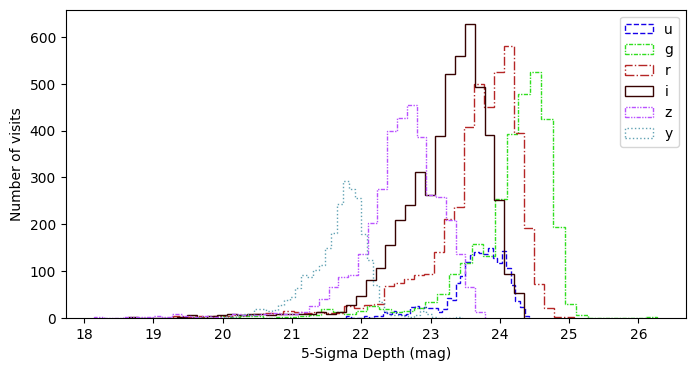

In [33]:
fig = plt.figure(figsize=(8, 4))
for f, filt in enumerate(filter_names):
    plt.hist(df.query("band == @filt")['fiveSigmaDepth'],
             bins=40, histtype='step',
             ls=filter_linestyles[filt],
             color=filter_colors_list[f], label=filt)
plt.legend(loc='best')
plt.xlabel("5-Sigma Depth (mag)")
plt.ylabel("Number of visits")
plt.show()

> **Figure 5:** The number of visits in bins of $5\sigma$ depth for point sources, by filter.

### 4.2. Summary statistics

Recreate parts of the tables on the  <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html#sv-wide'> Science Validation survey summary webpage </a>. This section uses code from the LSSTCam summary notebook in the <a href="https://github.com/lsst-sims/sims_sv_survey/blob/main/notebooks/lsstcam_summary.ipynb">Sims SV Survey repo</a>.

Display a table of the number of visits by band for each of the small field survey areas with at least 50 visits total.

In [34]:
query = "observation_reason == 'field_survey_science'"
df_sfs = df.query(query).groupby(['target_name', 'band']).agg({'seq_num': 'count'})
df_sfs.rename({'seq_num': 'count'}, axis=1, inplace=True)
df_sfs = df_sfs.reset_index('band').pivot(columns=["band"]).droplevel(0, axis=1)
df_sfs = df_sfs[['u', 'g', 'r', 'i', 'z', 'y']]
df_sfs['all'] = df_sfs.sum(axis=1)
df_sfs = df_sfs.query("all > 50").sort_values('all')
table = tabulate(pd.DataFrame(df_sfs.round(0)), headers='keys')
table = table.replace('nan', '  0')
print(table)
del query, df_sfs, table

target_name         u    g    r    i    z    y    all
----------------  ---  ---  ---  ---  ---  ---  -----
Carina             22   16   23   63    0    0    124
Rubin_SV_280_-48   30   30   29   30   29    0    148
ELAIS_S1           11   30   30   30   35   30    166
Rubin_SV_320_-15    0   29   17  105   52   70    273
New_Horizons       36   49   70  108   74   23    360
Rubin_SV_216_-17    0   64   95  227    0    0    386
Rubin_SV_212_-7     0  139  236  123    0    0    498
Prawn             196  164  149   93   30    0    632
COSMOS            100   82  166  139  111   66    664
Trifid-Lagoon     235  196  122  115    0    0    668
M49               261  280  378  254    0    0   1173
Rubin_SV_225_-40  312  568  441  387  240  104   2052


Display a table of the number of visits, median seeing (FWHM), mean airmass, and timespan (time between first and last visit) for each of the small field survey areas with at least 50 visits total.

In [35]:
query = "observation_reason == 'field_survey_science'"
df_sfs = df.query(query).groupby(['target_name']).agg({'seq_num': 'count',
                                                       'seeingFwhmEff': 'median',
                                                       'airmass': 'mean',
                                                       'exp_midpt_mjd': np.ptp})
df_sfs.rename({'seq_num': 'nvisits',
               'seeingFwhmEff': 'median fwhm (arcsec)',
               'airmass': 'mean airmass',
               'exp_midpt_mjd': 'timespan (days)'}, axis=1, inplace=True)
df_sfs = df_sfs.query("nvisits > 50").sort_values('nvisits')
df_sfs['timespan (days)'] = df_sfs['timespan (days)'].astype(int) + 1
df_sfs.round(2)
table = tabulate(pd.DataFrame(df_sfs.round(2)), headers='keys')
table = table.replace('nan', '  0')
print(table)
del query, df_sfs, table

target_name         nvisits    median fwhm (arcsec)    mean airmass    timespan (days)
----------------  ---------  ----------------------  --------------  -----------------
Carina                  124                    0               1.22                  4
Rubin_SV_280_-48        148                    1.52            1.62                  1
ELAIS_S1                166                    1.38            1.03                 17
Rubin_SV_320_-15        273                    1.22            1.08                  6
New_Horizons            360                    1.05            1.1                  62
Rubin_SV_216_-17        386                    1.29            1.06                  8
Rubin_SV_212_-7         498                    1.21            1.26                  7
Prawn                   632                    1.37            1.2                  79
COSMOS                  664                    1.22            1.41                 15
Trifid-Lagoon           668                

Recreate the two tables above, but for the SV DDF, and include all fields (do not restrict to fields with >50 visits).

In [36]:
query = "observation_reason.str.contains('ddf')"
df_ddf = df.query(query).groupby(['observation_reason', 'band']).agg({'seq_num': 'count'})
df_ddf.rename({'seq_num': 'count'}, axis=1, inplace=True)
df_ddf = df_ddf.reset_index('band').pivot(columns=["band"]).droplevel(0, axis=1)
df_ddf = df_ddf[['u', 'g', 'r', 'i', 'z', 'y']]
df_ddf['all'] = df_ddf.sum(axis=1)
df_ddf = df_ddf.query("all > 0").sort_values('all')
table = tabulate(pd.DataFrame(df_ddf.round(0)), headers='keys')
table = table.replace('nan', '  0')
print(table)
del query, df_ddf, table

observation_reason      u    g    r    i    z    y    all
--------------------  ---  ---  ---  ---  ---  ---  -----
ddf_xmm_lss            30    0    0    0    0    0     30
ddf_edfs_a              0   20   21   28   18    0     87
ddf_edfs_b              0   24   21   29   18    0     92
ddf_ecdfs               0   36   39   41   44    0    160
ddf_elaiss1            39  101  103  168  112   16    539


In [37]:
query = "observation_reason.str.contains('ddf')"
df_ddf = df.query(query).groupby(['observation_reason']).agg({'seq_num': 'count',
                                                              'seeingFwhmEff': 'median',
                                                              'airmass': 'mean',
                                                              'exp_midpt_mjd': np.ptp})
df_ddf.rename({'seq_num': 'nvisits',
               'seeingFwhmEff': 'median fwhm (arcsec)',
               'airmass': 'mean airmass',
               'exp_midpt_mjd': 'timespan (days)'}, axis=1, inplace=True)
df_ddf = df_ddf.sort_values('nvisits')
df_ddf['timespan (days)'] = df_ddf['timespan (days)'].astype(int) + 1
df_ddf.round(2)
table = tabulate(pd.DataFrame(df_ddf.round(2)), headers='keys')
table = table.replace('nan', '  0')
print(table)
del query, df_ddf, table

observation_reason      nvisits    median fwhm (arcsec)    mean airmass    timespan (days)
--------------------  ---------  ----------------------  --------------  -----------------
ddf_xmm_lss                  30                    1.47            1.79                 10
ddf_edfs_a                   87                    1.32            1.79                 55
ddf_edfs_b                   92                    1.37            1.88                 55
ddf_ecdfs                   160                    1.51            1.92                 57
ddf_elaiss1                 539                    1.4             1.34                 84


## 5. MAF sky map

Recreate the sky map diagram in Figure 1.

The commissioning visits database file has been generated using the same format and schema as the Operations Simulations (opsim) databases, and so can be read by the MAF (Metric Analysis Frameworks) package from the `rubin_sim` package.

This section follows the Jupyter Notebook tutorial for visualizing the survey footprint in the <a href="https://github.com/lsst/rubin_sim_notebooks">rubin_sim_notebook repository</a>.

Set the path to the folder containing `rubin_sim` data in the RSP at data.lsst.cloud.

In [38]:
#os.environ['RUBIN_SIM_DATA_DIR'] = '/rubin/rubin_sim_data'

Define the "opsim" filename and the "run name" -- in this case, the name of the commissioning visits database.

In [39]:
opsim_fname = db_filename
temp = db_filename.split('/')[-1]
run_name = temp.split('.')[0]
print(run_name)

lsstcam_20250930


Define the metric to be plotted, in this case, `Nvisits` the number of visits. Define the size of the healpix to use for the map. Do not define any constraints, and include all visits.

In [40]:
metric = maf.metrics.CountMetric(col='observationStartMJD',
                                 metric_name='Nvisits')
nside = 64
slicer = maf.slicers.HealpixSlicer(nside=nside)
constraint = None

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


Bundle together the components of the metric.

In [41]:
bundle = maf.MetricBundle(metric, slicer, constraint, run_name=run_name)

Define the bundle group to plot.

In [42]:
group = maf.MetricBundleGroup({'nvisits': bundle},
                              opsim_fname, out_dir=output_path)

Calculate the metric. The following step will generate the file `lsstcam_20250930_Nvisits_HEAL.npz` in the `output_path` defined in Section 1.2.

In [43]:
group.run_all()

Show the plots for this metric.

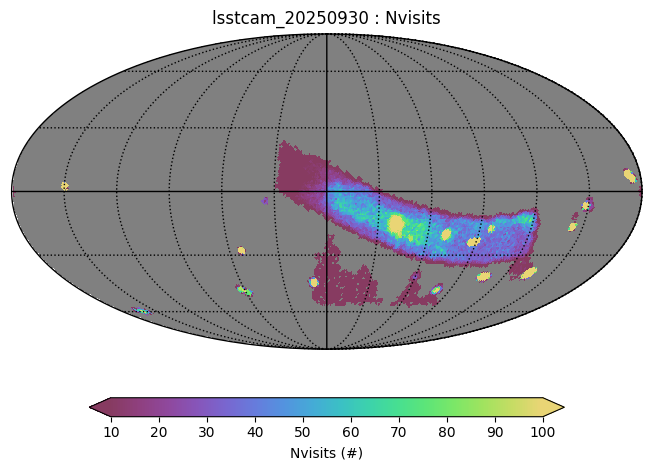

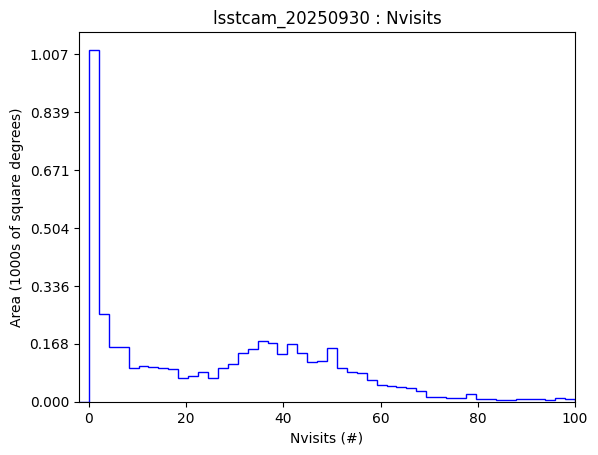

In [44]:
plot_dict = {'color_min': 10, 'color_max': 100,
             'x_min': -2, 'x_max': 100, 'bins': 50, 'extend': 'both'}
bundle.set_plot_dict(plot_dict)
_ = bundle.plot()

> **Figure 6:** Top, the sky map of the number of visits obtained during commissioning. Bottom, the sky area binned by number of visits, showing that most of the commissioning area was shallow.

Read more about they sky coverage for the SV wide-area survey on the  <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html#sv-wide'> Science Validation survey summary webpage </a>.

#### 5.1. Sky map for DDFs only

Create a sky map for only the DDFs, which will be where alert production will start in early 2026.

In [45]:
constraint = "observation_reason like \'%ddf%\'"
bundle = maf.MetricBundle(metric, slicer, constraint, run_name=run_name)
group = maf.MetricBundleGroup({'nvisits': bundle},
                              opsim_fname, out_dir=output_path)
group.run_all()

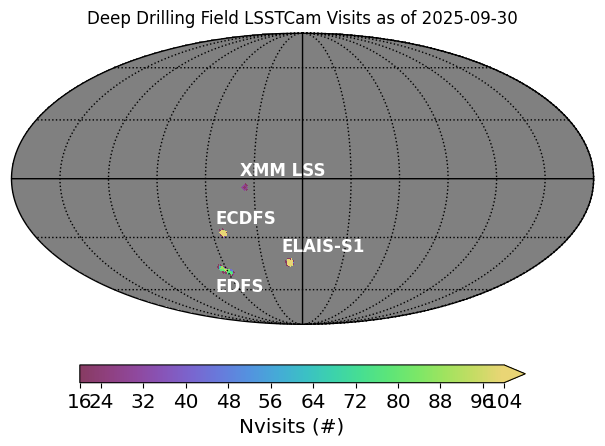

In [46]:
ph = maf.PlotHandler(savefig=False, fig_format='png', thumbnail=False, dpi=270)
ph.set_metric_bundles([bundle])
ph.plot(plot_func=maf.plots.HealpixSkyMap(),
        plot_dicts={'color_min': 20, 'color_max': 100, 'figsize': (6, 4),
                    'labelsize': 'x-large', 'fontsize': 'x-large', 'extend': 'max',
                    'title': 'Deep Drilling Field LSSTCam Visits as of 2025-09-30'})
plt.figtext(0.40, 0.62, 'XMM LSS', fontsize='large', fontweight='bold', color='white')
plt.figtext(0.36, 0.50, 'ECDFS', fontsize='large', fontweight='bold', color='white')
plt.figtext(0.36, 0.33, 'EDFS', fontsize='large', fontweight='bold', color='white')
plt.figtext(0.47, 0.43, 'ELAIS-S1', fontsize='large', fontweight='bold', color='white')
plt.show()

> **Figure 7:** The locations of the four Deep Drilling Fields (DDFs), with their names labeled. See Figure 1 for the field central coordinates.

## 6. Exercises for the learner

Of the 217 columns in the commissioning visits database, only nine were mentioned as key columns in Section 2.1. This did not include the column `cloud_extinction`.

Review the description of the `cloud_extinction` on the <a href='https://survey-strategy.lsst.io/progress/sv_status/sv_20250930.html'> Science Validation survey summary webpage </a>:
> The visit database *"also includes an estimate of the mean cloud extinction in the images. These are estimates based on the measured zeropoints for the images, compared to the expected zeropoint for an image in that bandpass at that airmass. A potential issue here is that visits with very heavy cloud extinction (or other problem with the quicklook image processing occuring immediately after image acquisition) may not succeed in measuring a zeropoint for the image at all, and thus no estimate for the cloud extinction will be possible either."*

As in Section 4.1, create a histogram of the `cloud_extinction` values. Use the function defined in Section 4.2 to calculate the mean cloud extinction in magnitudes for a subset of the visits.